In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Simulation Information
# Output file name common prefix/suffix
from datetime import datetime

# Category
cprefix1 = "sigrep-SHAC-BXN_sim_v10" # Large category
cprefix2 = "cA=0_5"     # Small category

# Common prefix
cprefix = cprefix1 + "_" + cprefix2 + "_"

# Current time (e.g., 20241001_235959)
now = datetime.now().strftime("%Y%m%d_%H%M%S")

# Common suffix
csuffix = "_" + now

In [3]:
import os
import glob
path = os.getcwd()

#Remove all files
for p in glob.glob('*.*', recursive=True):
    if os.path.isfile(p):
        os.remove(p)

In [4]:
import numpy as np
from numpy import arange,meshgrid,sqrt,exp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from google.colab import files
import pandas as pd

In [5]:
#Definition of functions
def Hill(x,gamma,K):
  return (x**gamma)/(x**gamma + K**gamma)

def HillH(x,gamma,K):
  return (K**gamma)/(x**gamma + K**gamma)

def DB(S,Smot,N,gammaN,KN,B):
  return np.heaviside(Smot-S,0.5) * (N**gammaN)/(N**gammaN + KN**gammaN)

def xscr(S,Sscr,b):
  return np.heaviside(S-Sscr,0.5) + b


In [6]:
# Simulation
def B_sim(Ms, xs, Nt, dt, Nx, dx):

    tau = 0.1
    shacloop = 1000

    N0 = 0.5

    bw = 5.0
    bh = 0.2

    aS = 1.0
    bS = 1.0
    cS = 1.0
    dS = 1.0
    aH = 0.1
    bH = 1.0
    cH = 4.0
    dH = 1.0
    aA = 1.0
    bA = 20.0
    cA = 0.5#control parameter
    dA = 0.1
    cC = 2.0
    dC = 1.0

    MB = 0.4
    gammaDB = 8
    KDB = 0.5
    Smot = 0.40503
    gammaDBN = 4
    KDBN = 0.005

    DN = 0.01
    DX = 0.8

    dX = 0.02
    p0 = 0.0
    p1 = 1.5
    gammaps = 8
    Kps = 0.5
    c = 1.5
    s = 30.0
    gammas = 2
    Ks = 9.0
    Sscr = 6.0
    bs = 0.0
    gammaNs = 2
    KNs = 0.02

    cBsp2 = MB/(dx**2)
    cNsp2 = DN/(dx**2)
    cXsp2 = DX/(dx**2)

    # Initial values
    B_t0 = np.array([0.0 for xj in range(Nx+1)])
    X_t0 = np.array([0.0 for xj in range(Nx+1)])
    N_t0 = np.array([0.0 for xj in range(Nx+1)])
    x = np.array([dx*xj for xj in range(Nx+1)])
    stmp = 0.0
    for xj in range(0,Nx+1):
      N_t0[xj] = N0
      if xj < bw:
        B_t0[xj] = bh*(bw - xj)/bw

    # Variables (time-series data)
    t_ts = np.array([0.0 for ti in range(Nt+1)])
    S_ts = np.array([0.0 for ti in range(Nt+1)])
    H_ts = np.array([0.0 for ti in range(Nt+1)])
    A_ts = np.array([0.0 for ti in range(Nt+1)])
    C_ts = np.array([0.0 for ti in range(Nt+1)])
    B_ts = np.array([[0.0 for xj in range(Nx+1)] for i in range(Nt+1)])
    X_ts = np.array([[0.0 for xj in range(Nx+1)] for i in range(Nt+1)])
    N_ts = np.array([[0.0 for xj in range(Nx+1)] for i in range(Nt+1)])
    Xbar_ts = np.array([0.0 for ti in range(Nt+1)])

    # Initialization
    t = 0.0
    S = 35.0
    H = 35.0
    A = 0.0
    C = 0.0
    B = B_t0
    X = X_t0
    N = N_t0
    Xbar = 0.0

    # Reset delta
    deltaS = 0.0
    deltaH = 0.0
    deltaA = 0.0
    deltaC = 0.0
    deltaB = np.array([0.0 for xj in range(Nx+1)])
    deltaX = np.array([0.0 for xj in range(Nx+1)])
    deltaN = np.array([0.0 for xj in range(Nx+1)])

    # Input variable
    t_ts[0] = t
    S_ts[0] = S
    H_ts[0] = H
    A_ts[0] = A
    C_ts[0] = C
    B_ts[0] = B
    X_ts[0] = X
    N_ts[0] = N
    Xbar_ts[0] = Xbar

    # Main loop
    for ti in range(0,Nt):
      ltmp = 0.0
      for tn in range(0,shacloop):
        deltaS = cS*H / (aS + bS*C) - dS*S
        deltaS = deltaS * dt / tau
        deltaH = cH / (aH + bH*A) - dH*H
        deltaH = deltaH * dt / tau
        deltaA = cA / (aA + bA*S) - dA*A
        deltaA = deltaA * dt / tau
        deltaC = cC*Xbar*A - dC*C
        deltaC = deltaC * dt / tau
        S = S + deltaS
        H = H + deltaH
        A = A + deltaA
        C = C + deltaC
      for xj in range(1,Nx):  #from 1 to Nx-1
        deltaB[xj] = DB(S,Smot,N[xj],gammaDBN,KDBN,B[xj])*(B[xj+1]-2.0*B[xj]+B[xj-1]) + 0.25*(DB(S,Smot,N[xj+1],gammaDBN,KDBN,B[xj+1])-DB(S,Smot,N[xj-1],gammaDBN,KDBN,B[xj-1]))*(B[xj+1]-B[xj-1])
        deltaB[xj] = cBsp2 * deltaB[xj] + (p0 + p1*xscr(S,Sscr,0))*B[xj]*N[xj]
        deltaB[xj] = deltaB[xj] * dt
        deltaN[xj] = cNsp2 * (N[xj+1]-2.0*N[xj]+N[xj-1]) - c*B[xj]*N[xj]
        deltaN[xj] = deltaN[xj] * dt
        deltaX[xj] = cXsp2 * (X[xj+1]-2.0*X[xj]+X[xj-1]) + s*B[xj]*xscr(S,Sscr,bs)*Hill(N[xj],gammaNs,KNs) - dX*X[xj]
        deltaX[xj] = deltaX[xj] * dt
      # Boundary conditions
      deltaB[0] = deltaB[1]
      deltaB[Nx] = deltaB[Nx-1]
      deltaN[0] = deltaN[1]
      deltaN[Nx] = deltaN[Nx-1]
      deltaX[0] = deltaX[1]
      deltaX[Nx] = deltaX[Nx-1]
      # Update variables
      t = t + dt
      B = B + deltaB
      N = N + deltaN
      X = X + deltaX
      Xbar = max(X)
      # Store data
      t_ts[ti+1] = t
      S_ts[ti+1] = S
      H_ts[ti+1] = H
      A_ts[ti+1] = A
      C_ts[ti+1] = C
      B_ts[ti+1] = B
      N_ts[ti+1] = N
      X_ts[ti+1] = X
      Xbar_ts[ti+1] = Xbar

    return Xbar_ts, B_ts, N_ts, X_ts, S_ts, H_ts, A_ts, C_ts, Xbar_ts

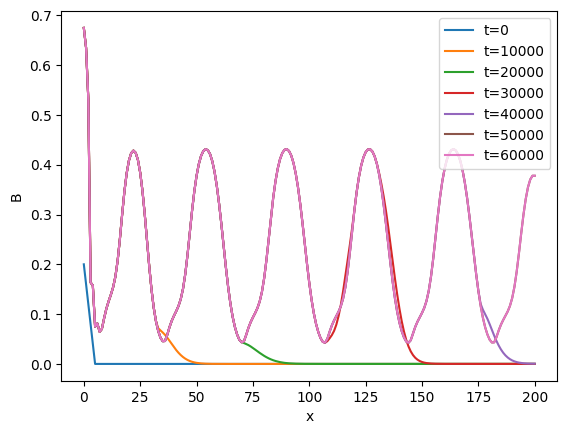

In [7]:
# Running simulations
Nt = 60000
dt = 0.01
Nx = 200
dx = 0.8
Ms_index = [1.0]
xs = 0.1
t = range(Nt+1)

for i in range(1):
  Temp = B_sim(Ms_index[i],xs,Nt,dt,Nx,dx)

xi = range(Nx+1)

plt.plot(xi, Temp[1][0], label=f"t=0")
plt.plot(xi, Temp[1][10000], label=f"t=10000")
plt.plot(xi, Temp[1][20000], label=f"t=20000")
plt.plot(xi, Temp[1][30000], label=f"t=30000")
plt.plot(xi, Temp[1][40000], label=f"t=40000")
plt.plot(xi, Temp[1][50000], label=f"t=50000")
plt.plot(xi, Temp[1][60000], label=f"t=60000")

plt.xlabel('x')
plt.ylabel('B')
plt.legend(loc='best')

In [8]:
# Colony boundary, peak1, peak2 & total bacterial cells
bw = 5.0
xjb_ts = np.array([0.0 for ti in range(Nt+1)])
xjp1_ts = np.array([0.0 for ti in range(Nt+1)])
xjp2_ts = np.array([0.0 for ti in range(Nt+1)])
totalB_ts = np.array([0.0 for ti in range(Nt+1)])
tmig1 = 0.0
tgrowth1 = 0.0
tmig2 = 0.0
tgrowth2 = 0.0
Smot = 0.40503

bth = 0.025 #threshold
xjb = (bw-1)*dx
totalB = 0.0
xjp1 = 0.0
xjp2 = 0.0
for xj in range(0,Nx+1):  #from 0 to Nx
  totalB = totalB + Temp[1][0][xj]
xjb_ts[0] = xjb
xjp1_ts[0] = 0.0
xjp2_ts[0] = 0.0
totalB_ts[0] = totalB
for ti in range(0,Nt):
  if Temp[4][ti] >= Smot and Temp[4][ti+1] < Smot and ti<Nt:
    if tmig1 == 0.0:
      tmig1 = (ti+1)*dt
    elif tmig2 == 0.0:
      tmig2 = (ti+1)*dt
  if Temp[4][ti] <= Smot and Temp[4][ti+1] > Smot and ti<Nt:
    if tgrowth1 == 0.0:
      tgrowth1 = (ti+1)*dt
    elif tgrowth2 == 0.0:
      tgrowth2 = (ti+1)*dt
  totalB = 0.0
  xjp1 = 0.0
  xjp2 = 0.0
  for xj in range(0,Nx+1):  #from 0 to Nx
    totalB = totalB + Temp[1][ti][xj]
    if Temp[1][ti+1][xj] > bth:
      xjb = xj*dx
    if xj >0 and xj < Nx and Temp[1][ti+1][xj-1] <= Temp[1][ti+1][xj] and Temp[1][ti+1][xj] >= Temp[1][ti+1][xj+1] and xjp1 < 0.5*dx:
      xjp1 = xj*dx
    if xj >0 and xj < Nx and Temp[1][ti+1][xj-1] <= Temp[1][ti+1][xj] and Temp[1][ti+1][xj] >= Temp[1][ti+1][xj+1] and xjp1 > 0.5*dx and xj*dx>xjp1 and xjp2 < 0.5*dx:
      xjp2 = xj*dx
  xjb_ts[ti+1] = xjb
  totalB_ts[ti+1] = totalB
  xjp1_ts[ti+1] = xjp1
  xjp2_ts[ti+1] = xjp2

filenamepst = "pst_" + cprefix + "res-ts" + csuffix + ".csv"
pst = [tmig1,tgrowth1,tmig2,tgrowth2]
np.savetxt(f'{filenamepst}', pst)

/tmp/ipykernel_23339/449499205.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')
/tmp/ipykernel_23339/449499205.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


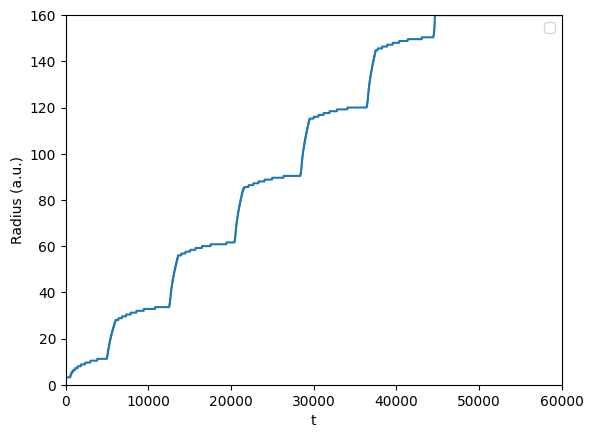

In [9]:
plt.plot(xjb_ts)
plt.xlim([0,60000])
plt.ylim([0,160])
plt.legend(loc='best')

plt.xlabel('t')
plt.ylabel('Radius (a.u.)')
plt.legend(loc='best')

/tmp/ipykernel_23339/746524365.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


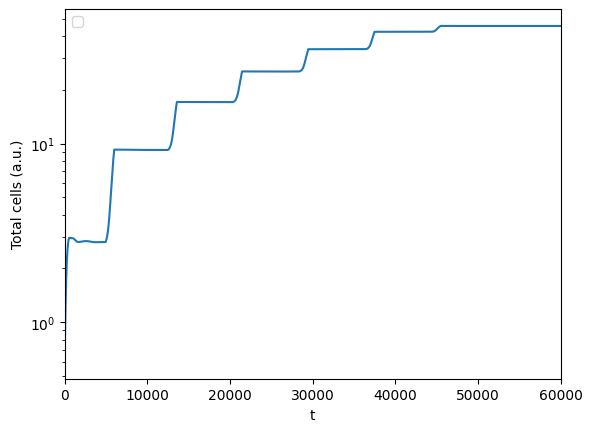

In [10]:
filenamelogtotalBeps = "log_totalB_" + cprefix + "res-ts" + csuffix + ".eps"
plt.plot(totalB_ts)
plt.xlim([0,60000])
#plt.ylim([0,25])
plt.legend(loc='best')

plt.xlabel('t')
plt.ylabel('Total cells (a.u.)')
plt.yscale('log')

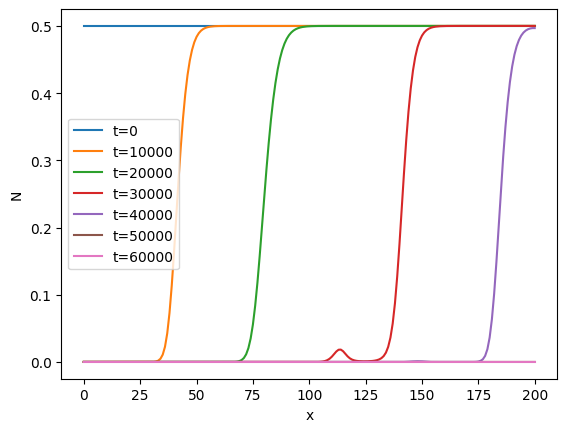

In [11]:
plt.plot(xi, Temp[2][0], label=f"t=0")
plt.plot(xi, Temp[2][10000], label=f"t=10000")
plt.plot(xi, Temp[2][20000], label=f"t=20000")
plt.plot(xi, Temp[2][30000], label=f"t=30000")
plt.plot(xi, Temp[2][40000], label=f"t=40000")
plt.plot(xi, Temp[2][50000], label=f"t=50000")
plt.plot(xi, Temp[2][60000], label=f"t=60000")

plt.xlabel('x')
plt.ylabel('N')
plt.legend(loc='best')

In [12]:
#save
filenameB = "B_" + cprefix + "res-ts" + csuffix + ".csv"
filenameX = "X_" + cprefix + "res-ts" + csuffix + ".csv"
filenameN = "N_" + cprefix + "res-ts" + csuffix + ".csv"
filenamexjb = "xjb_" + cprefix + "res-ts" + csuffix + ".csv"
filenametotalB = "totalB_" + cprefix + "res-ts" + csuffix + ".csv"
filenamexjp1 = "xjp1_" + cprefix + "res-ts" + csuffix + ".csv"
filenamexjp2 = "xjp2_" + cprefix + "res-ts" + csuffix + ".csv"
filenameS = "S_" + cprefix + "res-ts" + csuffix + ".csv"
filenameH = "H_" + cprefix + "res-ts" + csuffix + ".csv"
filenameA = "A_" + cprefix + "res-ts" + csuffix + ".csv"
filenameC = "C_" + cprefix + "res-ts" + csuffix + ".csv"
filenameXbar = "Xbar_" + cprefix + "res-ts" + csuffix + ".csv"
np.savetxt(f'{filenameB}', Temp[1])
np.savetxt(f'{filenameX}', Temp[3])
np.savetxt(f'{filenameN}', Temp[2])
np.savetxt(f'{filenamexjb}', xjb_ts)
np.savetxt(f'{filenametotalB}', totalB_ts)
np.savetxt(f'{filenamexjp1}', xjp1_ts)
np.savetxt(f'{filenamexjp2}', xjp2_ts)
np.savetxt(f'{filenameS}', Temp[4])
np.savetxt(f'{filenameH}', Temp[5])
np.savetxt(f'{filenameA}', Temp[6])
np.savetxt(f'{filenameC}', Temp[7])
np.savetxt(f'{filenameXbar}', Temp[8])

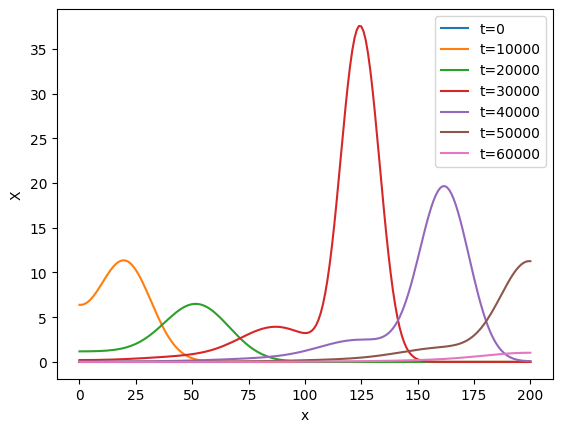

In [13]:
plt.plot(xi, Temp[3][0], label=f"t=0")
plt.plot(xi, Temp[3][10000], label=f"t=10000")
plt.plot(xi, Temp[3][20000], label=f"t=20000")
plt.plot(xi, Temp[3][30000], label=f"t=30000")
plt.plot(xi, Temp[3][40000], label=f"t=40000")
plt.plot(xi, Temp[3][50000], label=f"t=50000")
plt.plot(xi, Temp[3][60000], label=f"t=60000")

plt.xlabel('x')
plt.ylabel('X')
plt.legend(loc='best')

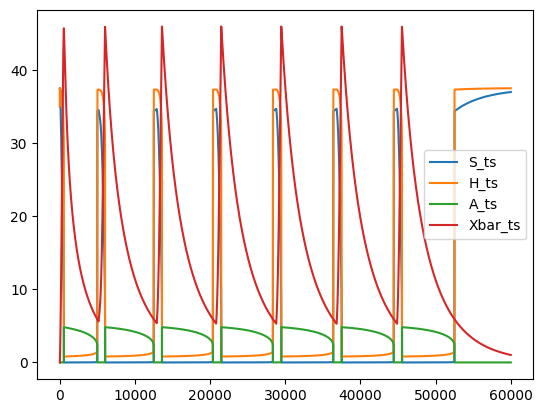

In [14]:
plt.plot(Temp[4], label=f"S_ts")
plt.plot(Temp[5], label=f"H_ts")
plt.plot(Temp[6], label=f"A_ts")
#plt.plot(Temp[7], label=f"C_ts")
plt.plot(Temp[8], label=f"Xbar_ts")
plt.legend(loc='best')

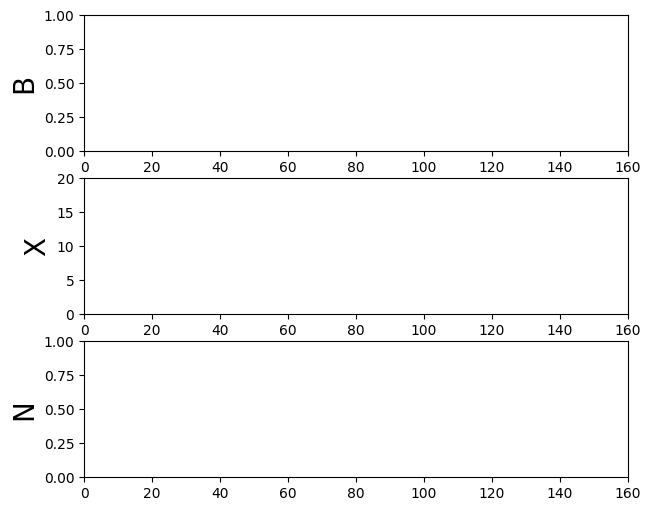

In [15]:
x = np.array([dx*xj for xj in range(Nx+1)])

fig = plt.figure(figsize=(8, 6))
axb = fig.add_subplot(311)
axx = fig.add_subplot(312)
axn = fig.add_subplot(313)
axb.grid(False)
axx.grid(False)
axn.grid(False)
imgs = []

yticks = np.arange(-50, 30, 10)
axb.set(aspect=40.0)
axb.set_xlim([0,Nx*dx])
axb.set_ylim([0,1])
axb.set_ylabel("B",fontsize=20)
axx.set(aspect=2.0)
axx.set_xlim([0,Nx*dx])
axx.set_ylim([0,20])
axx.set_ylabel("X",fontsize=20)
axn.set(aspect=40.0)
axn.set_xlim([0,Nx*dx])
axn.set_ylim([0,1])
axn.set_ylabel("N",fontsize=20)

skipr = 500
for ti in range(0,Nt+1):
  if ti % skipr == 0:
    im1f = axb.fill_between(x,Temp[1][ti],0, facecolor='#662d91', alpha=1.0)
    im1 = axb.plot(x, Temp[1][ti], label=f"B", color = "black")
    im1t = axb.text(0.5, 1.05, "t="+ str(dt*ti), fontsize=20, ha='center', transform=axb.transAxes)
    im2f = axx.fill_between(x,Temp[3][ti],0, facecolor='#32cd32', alpha=1.0)
    im2 = axx.plot(x, Temp[3][ti], label=f"X", color = "black")
    im3f = axn.fill_between(x,Temp[2][ti],0, facecolor='#d2691e', alpha=1.0)
    im3 = axn.plot(x, Temp[2][ti], label=f"N", color = "black")
    imgs.append([im1f] + im1 + [im1t] + [im2f] + im2 + [im3f] + im3)

ani = animation.ArtistAnimation(fig, imgs, interval=100)
filename3 = cprefix + "res-ts" + csuffix + ".gif"
ani.save(filename3, writer="imagemagick")
